In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [117]:
df_train = pd.read_csv('./Data/raw/df_train.csv')
df_test = pd.read_csv('./Data/raw/df_test.csv')
display(df_train.head())
display(df_train.head())

C:\Users\Laura\AppData\Local\Temp\ipykernel_2476\793633654.py:1: DtypeWarning: Columns (0: type_y, 1: locale, 2: locale_name, 3: description, 4: transferred) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv('./Data/raw/df_train.csv')
C:\Users\Laura\AppData\Local\Temp\ipykernel_2476\793633654.py:2: DtypeWarning: Columns (0: type_y, 1: locale, 2: locale_name, 3: description, 4: transferred) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv('./Data/raw/df_test.csv')


,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,transactions,dcoilwtico,type_y,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1,1194,2013-01-01,42,CELEBRATION,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
2,1193,2013-01-01,42,BREAD/BAKERY,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
3,1192,2013-01-01,42,BOOKS,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
4,1191,2013-01-01,42,BEVERAGES,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False


,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,transactions,dcoilwtico,type_y,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1,1194,2013-01-01,42,CELEBRATION,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
2,1193,2013-01-01,42,BREAD/BAKERY,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
3,1192,2013-01-01,42,BOOKS,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
4,1191,2013-01-01,42,BEVERAGES,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False


In [118]:
# Definición de las columnas que no aportan valor predictivo directo
columnas_a_eliminar = ['id', 'store_nbr']

# Aplicamos la eliminación en el dataframe de entrenamiento
df_train.drop(columns=columnas_a_eliminar, inplace=True, errors='ignore')

# Aplicamos exactamente la misma eliminación en el dataframe de test
df_test.drop(columns=columnas_a_eliminar, inplace=True, errors='ignore')

# Verificamos los cambios
print("Columnas en TRAIN:", df_train.columns.tolist())
print("Columnas en TEST:", df_test.columns.tolist())

Columnas en TRAIN: ['date', 'family', 'sales', 'onpromotion', 'city', 'state', 'type_x', 'cluster', 'transactions', 'dcoilwtico', 'type_y', 'locale', 'locale_name', 'description', 'transferred']
Columnas en TEST: ['date', 'family', 'sales', 'onpromotion', 'city', 'state', 'type_x', 'cluster', 'transactions', 'dcoilwtico', 'type_y', 'locale', 'locale_name', 'description', 'transferred']


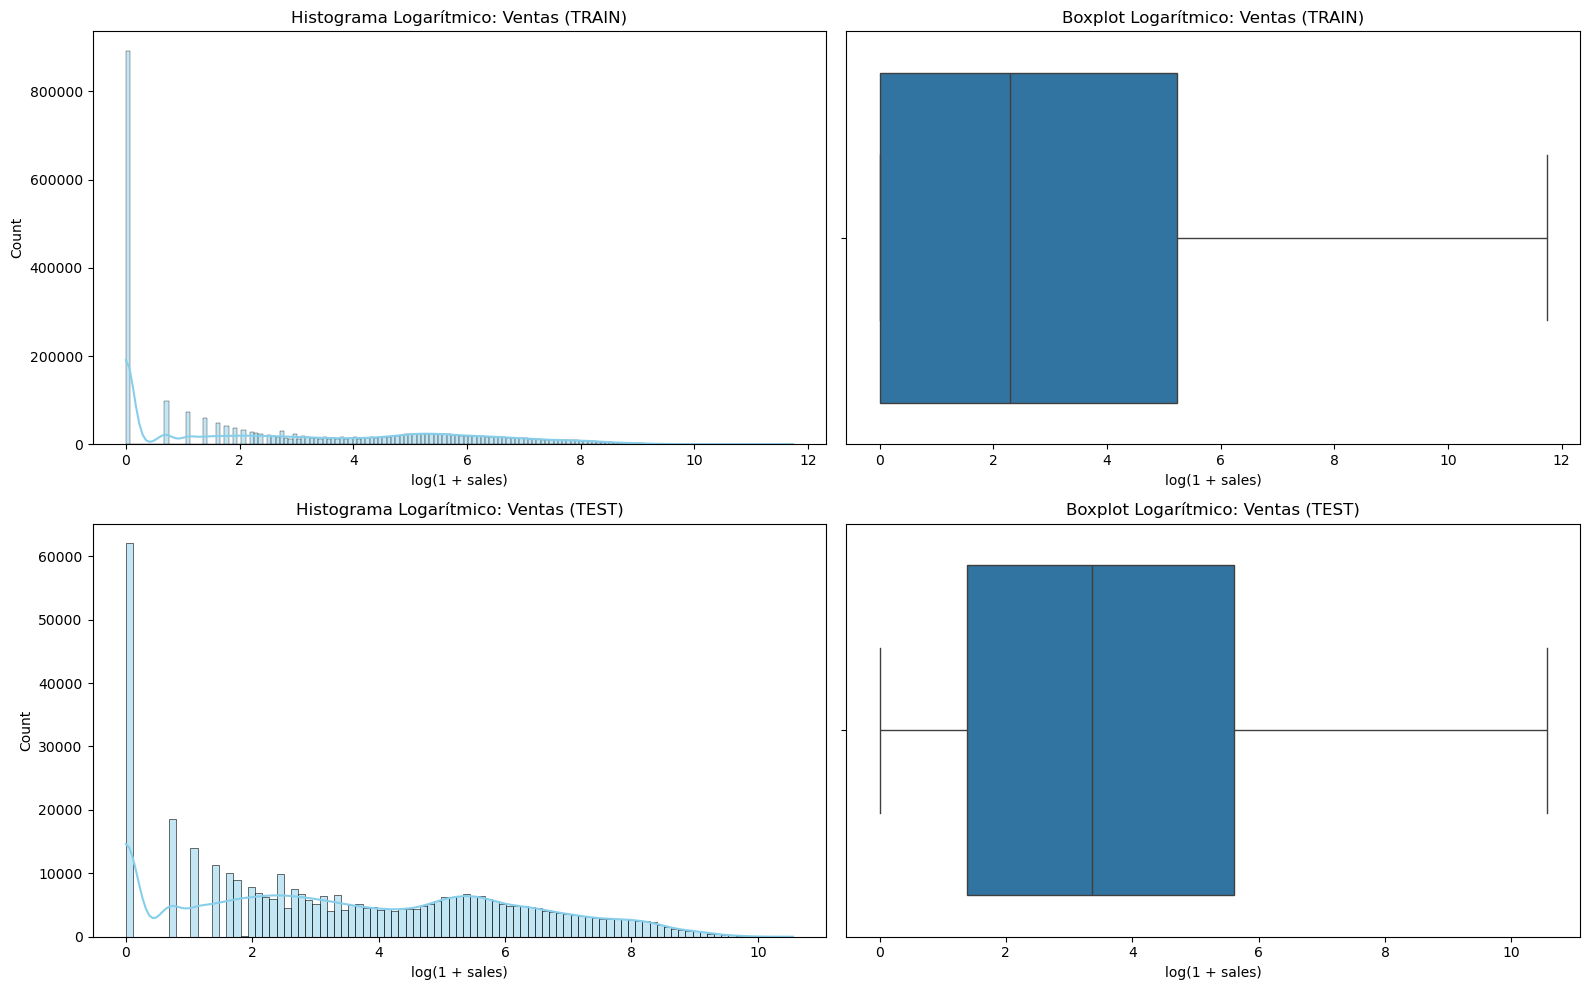

Nulos en sales_log (Train): 0
Nulos en sales_log (Test): 0


In [119]:
# 1. Aplicar transformación logarítmica en TRAIN y TEST
df_train['sales_log'] = np.log1p(df_train['sales'])
df_test['sales_log'] = np.log1p(df_test['sales'])

# 2. Configuración de la figura para mostrar 4 gráficos (2 por dataset)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- GRÁFICOS PARA TRAIN ---
# Histograma Train
sns.histplot(df_train['sales_log'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Histograma Logarítmico: Ventas (TRAIN)')
axes[0, 0].set_xlabel('log(1 + sales)')

# Boxplot Train
sns.boxplot(x=df_train['sales_log'], ax=axes[0, 1])
axes[0, 1].set_title('Boxplot Logarítmico: Ventas (TRAIN)')
axes[0, 1].set_xlabel('log(1 + sales)')

# --- GRÁFICOS PARA TEST ---
# Histograma Test
sns.histplot(df_test['sales_log'], kde=True, ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Histograma Logarítmico: Ventas (TEST)')
axes[1, 0].set_xlabel('log(1 + sales)')

# Boxplot Test
sns.boxplot(x=df_test['sales_log'], ax=axes[1, 1])
axes[1, 1].set_title('Boxplot Logarítmico: Ventas (TEST)')
axes[1, 1].set_xlabel('log(1 + sales)')

plt.tight_layout()
plt.show()

# 3. Verificación de nulos (importante después de transformar)
print(f"Nulos en sales_log (Train): {df_train['sales_log'].isnull().sum()}")
print(f"Nulos en sales_log (Test): {df_test['sales_log'].isnull().sum()}")

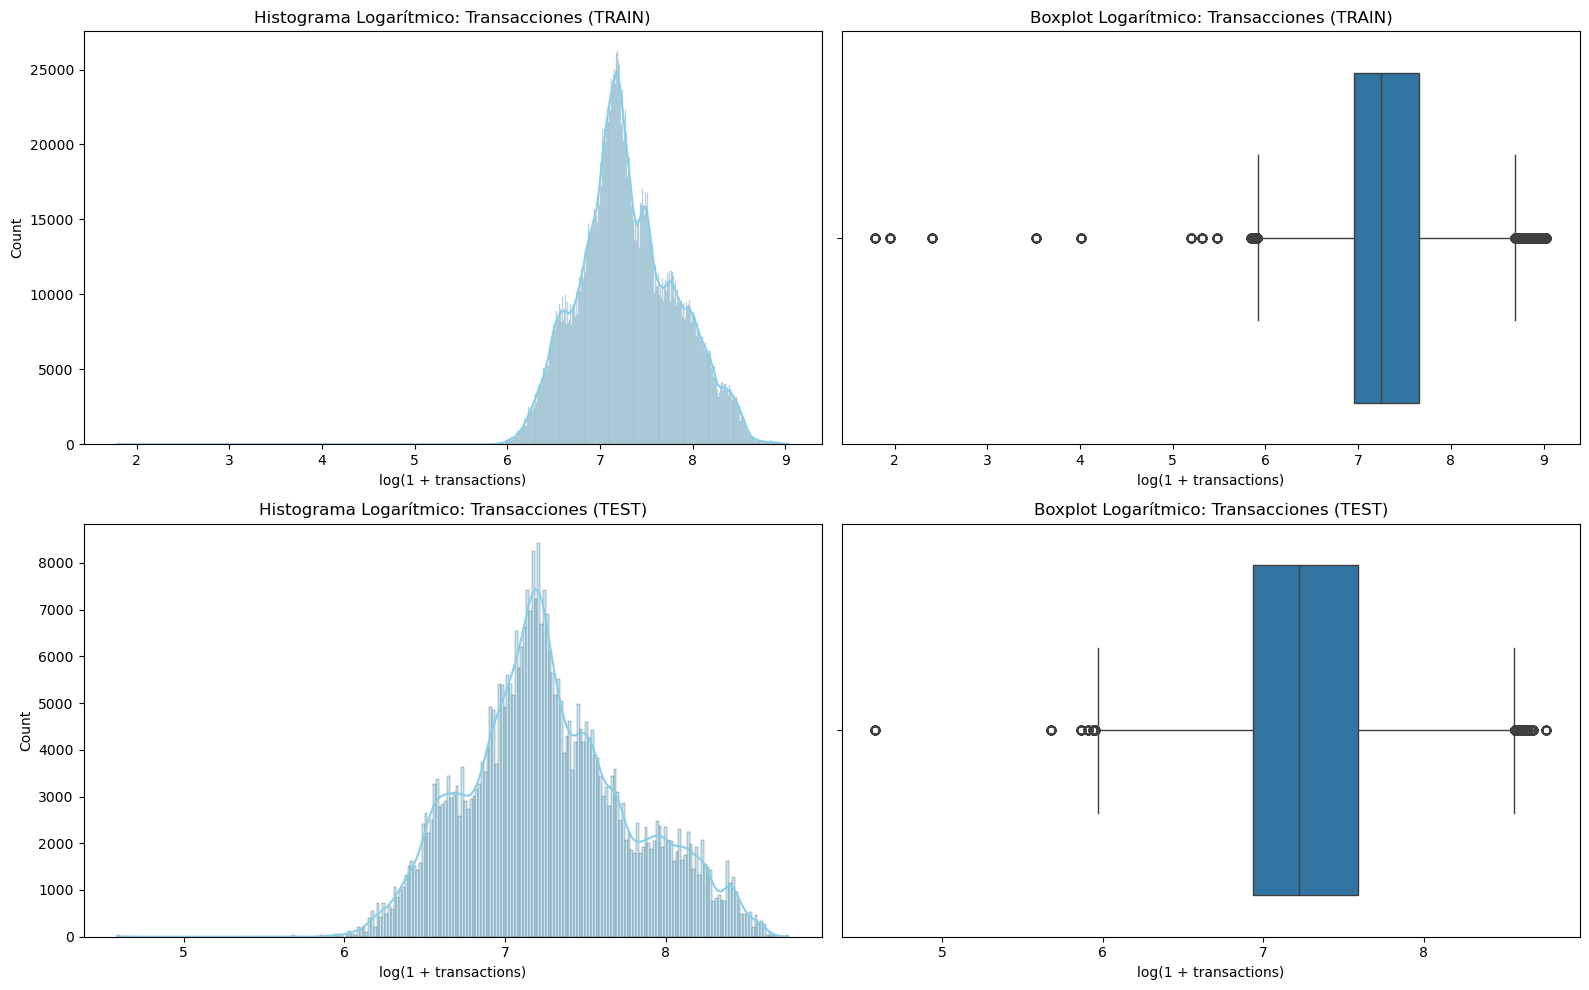

Columna 'transactions_log' lista en Train: True
Columna 'transactions_log' lista en Test: True


In [120]:
# 1. Aplicar transformación logarítmica en TRAIN y TEST
df_train['transactions_log'] = np.log1p(df_train['transactions'])
df_test['transactions_log'] = np.log1p(df_test['transactions'])

# 2. Configuración de la figura (2 filas, 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- GRÁFICOS PARA TRAIN ---
# Histograma Train
sns.histplot(df_train['transactions_log'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Histograma Logarítmico: Transacciones (TRAIN)')
axes[0, 0].set_xlabel('log(1 + transactions)')

# Boxplot Train
sns.boxplot(x=df_train['transactions_log'], ax=axes[0, 1])
axes[0, 1].set_title('Boxplot Logarítmico: Transacciones (TRAIN)')
axes[0, 1].set_xlabel('log(1 + transactions)')

# --- GRÁFICOS PARA TEST ---
# Histograma Test
sns.histplot(df_test['transactions_log'], kde=True, ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Histograma Logarítmico: Transacciones (TEST)')
axes[1, 0].set_xlabel('log(1 + transactions)')

# Boxplot Test
sns.boxplot(x=df_test['transactions_log'], ax=axes[1, 1])
axes[1, 1].set_title('Boxplot Logarítmico: Transacciones (TEST)')
axes[1, 1].set_xlabel('log(1 + transactions)')

plt.tight_layout()
plt.show()

# 3. Verificación de las nuevas columnas
print(f"Columna 'transactions_log' lista en Train: {'transactions_log' in df_train.columns}")
print(f"Columna 'transactions_log' lista en Test: {'transactions_log' in df_test.columns}")

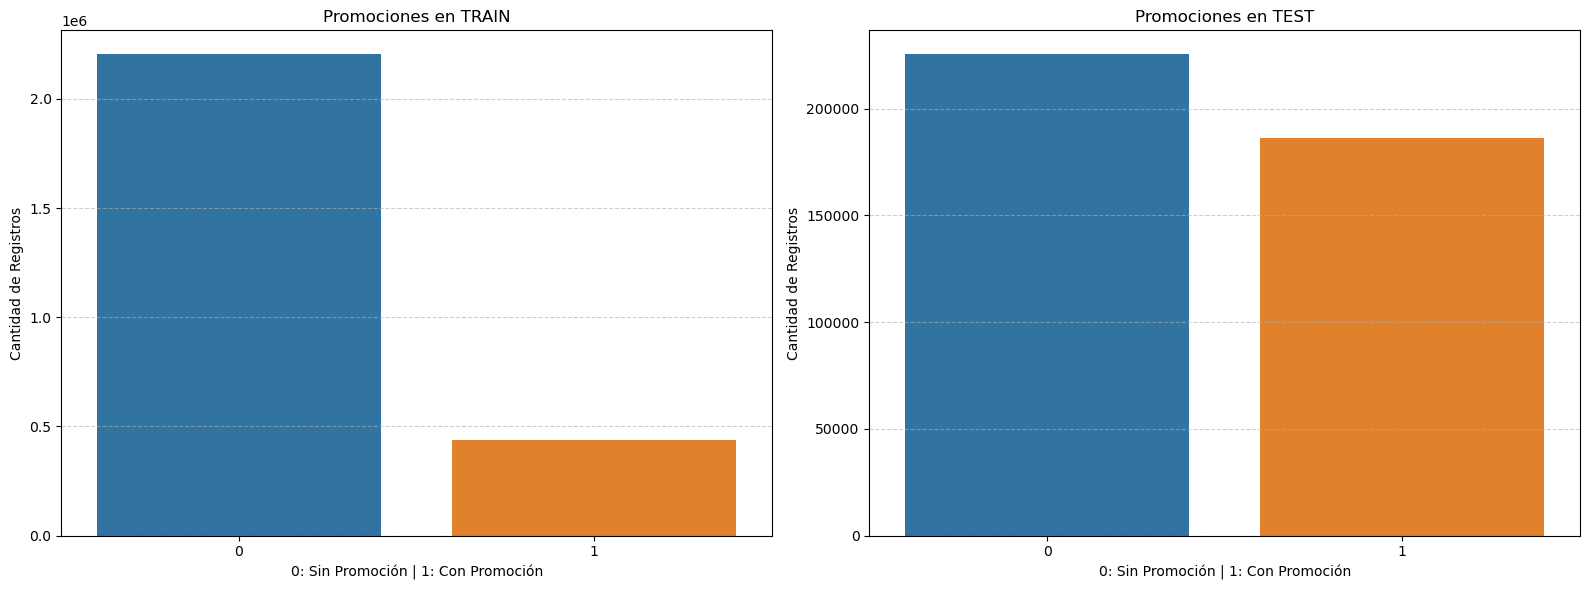

Variable 'has_promotion' creada y 'onpromotion' eliminada en ambos datasets.


In [121]:
# 1. Crear la variable binaria 'has_promotion' en TRAIN y TEST
df_train['has_promotion'] = (df_train['onpromotion'] > 0).astype(int)
df_test['has_promotion'] = (df_test['onpromotion'] > 0).astype(int)

# 2. Visualización comparativa (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Countplot para TRAIN
sns.countplot(x='has_promotion', data=df_train, ax=axes[0], hue='has_promotion', legend=False)
axes[0].set_title('Promociones en TRAIN')
axes[0].set_xlabel('0: Sin Promoción | 1: Con Promoción')
axes[0].set_ylabel('Cantidad de Registros')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Countplot para TEST
sns.countplot(x='has_promotion', data=df_test, ax=axes[1], hue='has_promotion', legend=False)
axes[1].set_title('Promociones en TEST')
axes[1].set_xlabel('0: Sin Promoción | 1: Con Promoción')
axes[1].set_ylabel('Cantidad de Registros')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. Eliminar la variable original 'onpromotion' en ambos
df_train.drop(columns=['onpromotion'], inplace=True, errors='ignore')
df_test.drop(columns=['onpromotion'], inplace=True, errors='ignore')

print("Variable 'has_promotion' creada y 'onpromotion' eliminada en ambos datasets.")

In [122]:
# 1. Tratamiento de nulos en TRAIN y TEST
# Usamos ffill (hacia adelante) y bfill (hacia atrás) para completar huecos
df_train['dcoilwtico'] = df_train['dcoilwtico'].ffill().bfill()
df_test['dcoilwtico'] = df_test['dcoilwtico'].ffill().bfill()

# 2. Verificación de nulos restantes
print(f"Nulos en TRAIN: {df_train['dcoilwtico'].isnull().sum()}")
print(f"Nulos en TEST:  {df_test['dcoilwtico'].isnull().sum()}")

Nulos en TRAIN: 0
Nulos en TEST:  0


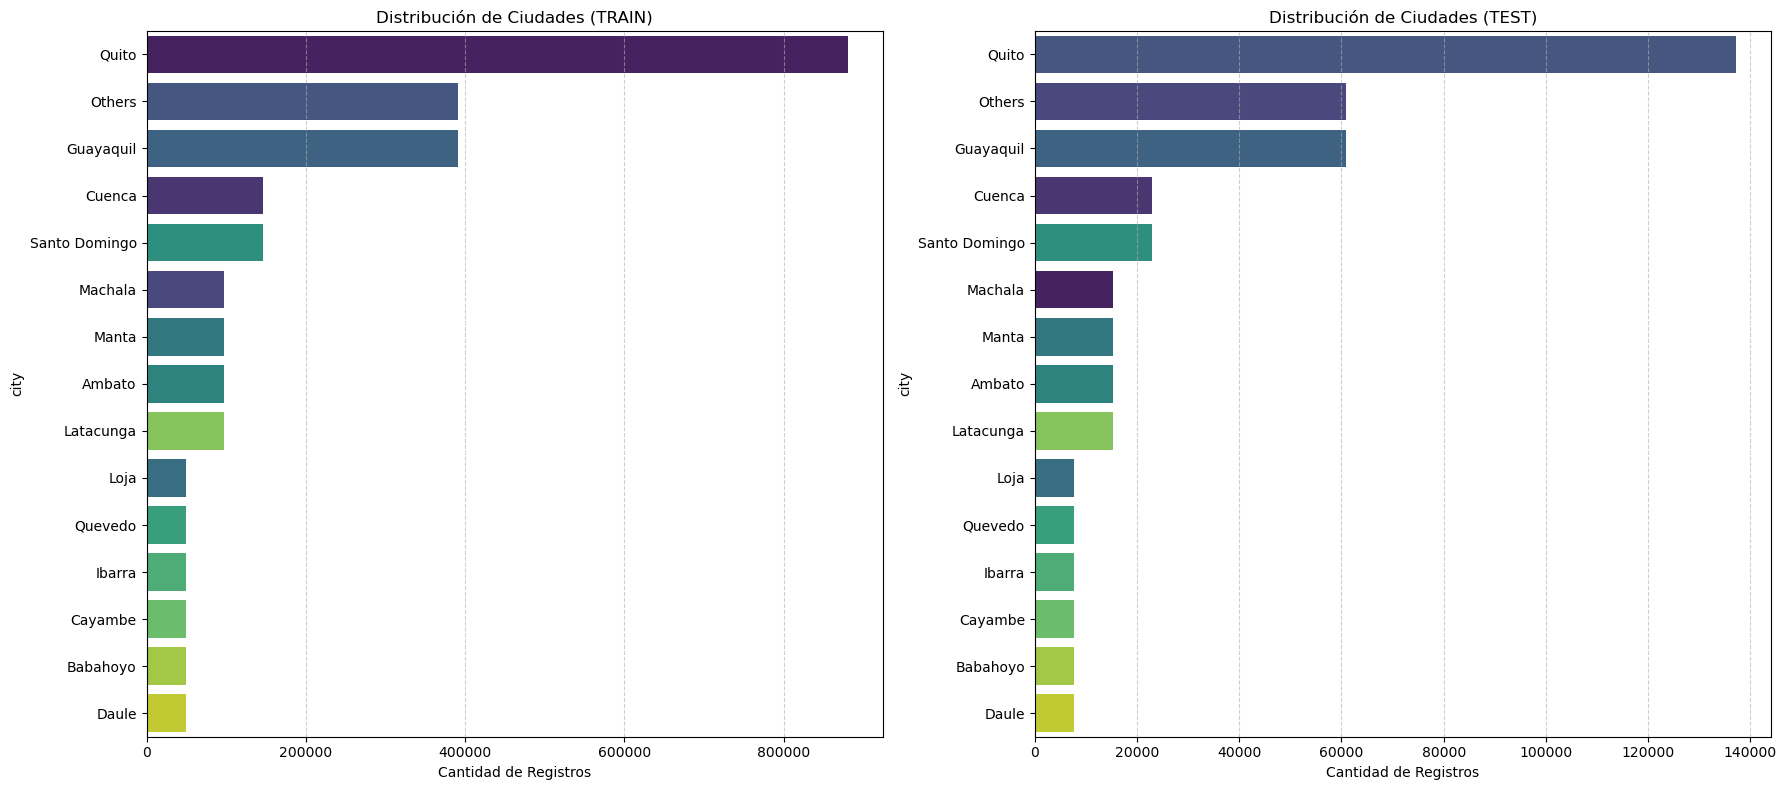

Categorías finales en TRAIN: <StringArray>
[        'Quito',        'Cuenca',       'Machala',        'Others',
     'Guayaquil',          'Loja',         'Manta',        'Ambato',
 'Santo Domingo',       'Quevedo',        'Ibarra',       'Cayambe',
     'Latacunga',      'Babahoyo',         'Daule']
Length: 15, dtype: str
Categorías finales en TEST: <StringArray>
[      'Machala',        'Cuenca',        'Others',         'Quito',
     'Guayaquil',          'Loja',         'Manta',        'Ambato',
 'Santo Domingo',       'Quevedo',        'Ibarra',       'Cayambe',
     'Latacunga',      'Babahoyo',         'Daule']
Length: 15, dtype: str


In [123]:
# 1. Definir la lista de ciudades a agrupar
ciudades_a_agrupar = [
    'Esmeraldas', 'El Carmen', 'Quininde', 'Riobamba', 'Trinitaria', 
    'Cotacachi', 'Playas', 'Libertad', 'Puyo', 'Guaranda', 'Salinas'
]

# 2. Reemplazar por "Others" en TRAIN y TEST
df_train['city'] = df_train['city'].replace(ciudades_a_agrupar, 'Others')
df_test['city'] = df_test['city'].replace(ciudades_a_agrupar, 'Others')

# 3. Visualización comparativa (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Gráfico para TRAIN
order_train = df_train['city'].value_counts().index
sns.countplot(y='city', data=df_train, order=order_train, palette='viridis', hue='city', legend=False, ax=axes[0])
axes[0].set_title('Distribución de Ciudades (TRAIN)')
axes[0].set_xlabel('Cantidad de Registros')
axes[0].grid(axis='x', linestyle='--', alpha=0.6)

# Gráfico para TEST
order_test = df_test['city'].value_counts().index
sns.countplot(y='city', data=df_test, order=order_test, palette='viridis', hue='city', legend=False, ax=axes[1])
axes[1].set_title('Distribución de Ciudades (TEST)')
axes[1].set_xlabel('Cantidad de Registros')
axes[1].grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. Confirmación de categorías finales
print("Categorías finales en TRAIN:", df_train['city'].unique())
print("Categorías finales en TEST:", df_test['city'].unique())

In [124]:
# 1. Asegurar formato datetime en ambos
df_train['date'] = pd.to_datetime(df_train['date'])
df_test['date'] = pd.to_datetime(df_test['date'])

# 2. Crear columnas temporales en TRAIN
df_train['day_of_week'] = df_train['date'].dt.day_name()
df_train['day'] = df_train['date'].dt.day
df_train['month'] = df_train['date'].dt.month
df_train['year'] = df_train['date'].dt.year

# 3. Crear columnas temporales en TEST
df_test['day_of_week'] = df_test['date'].dt.day_name()
df_test['day'] = df_test['date'].dt.day
df_test['month'] = df_test['date'].dt.month
df_test['year'] = df_test['date'].dt.year

# 4. Eliminar la columna 'date' original en ambos
df_train.drop(columns=['date'], inplace=True)
df_test.drop(columns=['date'], inplace=True)

print("Columnas temporales creadas en ambos datasets: day_of_week, day, month, year.")
print(f"\nColumnas en TRAIN: {df_train.columns.tolist()}")
print(f"Columnas en TEST: {df_test.columns.tolist()}")

Columnas temporales creadas en ambos datasets: day_of_week, day, month, year.

Columnas en TRAIN: ['family', 'sales', 'city', 'state', 'type_x', 'cluster', 'transactions', 'dcoilwtico', 'type_y', 'locale', 'locale_name', 'description', 'transferred', 'sales_log', 'transactions_log', 'has_promotion', 'day_of_week', 'day', 'month', 'year']
Columnas en TEST: ['family', 'sales', 'city', 'state', 'type_x', 'cluster', 'transactions', 'dcoilwtico', 'type_y', 'locale', 'locale_name', 'description', 'transferred', 'sales_log', 'transactions_log', 'has_promotion', 'day_of_week', 'day', 'month', 'year']


In [125]:
# Definimos el término clave
termino_terremoto = 'Terremoto'

# Aplicamos en Train
df_train['is_earthquake'] = df_train['description'].fillna('').str.contains(termino_terremoto).astype(int)

# Aplicamos en Test
df_test['is_earthquake'] = df_test['description'].fillna('').str.contains(termino_terremoto).astype(int)

print(f"Registros con terremoto en Train: {df_train['is_earthquake'].sum()}")
print(f"Registros con terremoto en Test: {df_test['is_earthquake'].sum()}")

Registros con terremoto en Train: 55242
Registros con terremoto en Test: 0


In [126]:
# Aplicamos en Train
df_train['is_holiday'] = df_train['locale_name'].notnull().astype(int)

# Aplicamos en Test
df_test['is_holiday'] = df_test['locale_name'].notnull().astype(int)

print(f"Días festivos identificados en Train: {df_train['is_holiday'].sum()}")
print(f"Registros con terremoto en Test: {df_test['is_holiday'].sum()}")

Días festivos identificados en Train: 449064
Registros con terremoto en Test: 53460


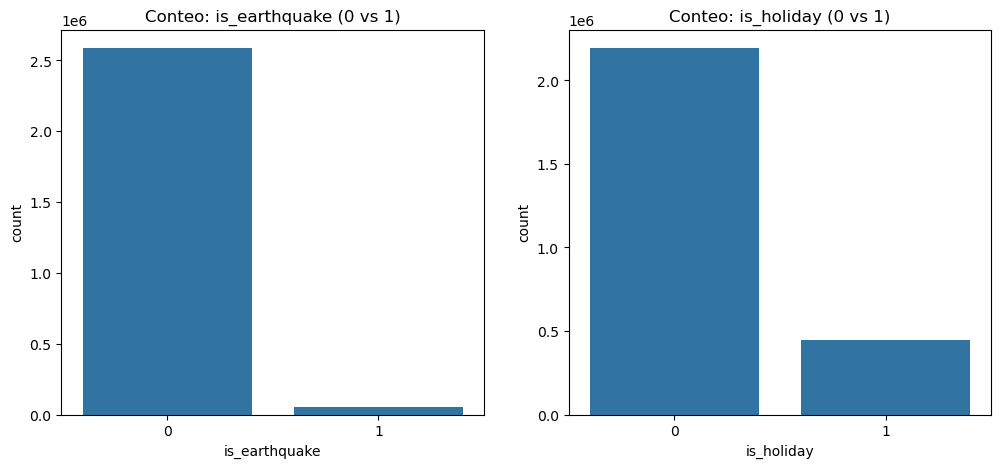

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico para Terremoto
sns.countplot(x='is_earthquake', data=df_train, ax=axes[0])
axes[0].set_title('Conteo: is_earthquake (0 vs 1)')

# Gráfico para Festivos
sns.countplot(x='is_holiday', data=df_train, ax=axes[1])
axes[1].set_title('Conteo: is_holiday (0 vs 1)')

plt.show()

In [128]:
columnas_sucias = ['description', 'locale_name']

# Eliminamos de ambos datasets
df_train.drop(columns=columnas_sucias, inplace=True, errors='ignore')
df_test.drop(columns=columnas_sucias, inplace=True, errors='ignore')

print("Columnas originales eliminadas. El dataset está limpio.")

Columnas originales eliminadas. El dataset está limpio.


In [129]:
# 1. Definir las columnas que ya no aportan valor o generan ruido
columnas_a_eliminar = ['type_y', 'locale']

# 2. Eliminar de TRAIN y TEST
df_train.drop(columns=columnas_a_eliminar, inplace=True, errors='ignore')
df_test.drop(columns=columnas_a_eliminar, inplace=True, errors='ignore')

# 3. Verificación rápida
print("Columnas eliminadas: type_y, locale.")
print(f"¿Existe 'type_y' en Train?: {'type_y' in df_train.columns}")
print(f"¿Existe 'locale' en Train?: {'locale' in df_train.columns}")

print(f"¿Existe 'type_y' en Train?: {'type_y' in df_test.columns}")
print(f"¿Existe 'locale' en Train?: {'locale' in df_test.columns}")

# 4. Mostrar cómo queda el dataset
print("\nColumnas actuales para el modelo:")
print(df_train.columns.tolist())
print(df_test.columns.tolist())

Columnas eliminadas: type_y, locale.
¿Existe 'type_y' en Train?: False
¿Existe 'locale' en Train?: False
¿Existe 'type_y' en Train?: False
¿Existe 'locale' en Train?: False

Columnas actuales para el modelo:
['family', 'sales', 'city', 'state', 'type_x', 'cluster', 'transactions', 'dcoilwtico', 'transferred', 'sales_log', 'transactions_log', 'has_promotion', 'day_of_week', 'day', 'month', 'year', 'is_earthquake', 'is_holiday']
['family', 'sales', 'city', 'state', 'type_x', 'cluster', 'transactions', 'dcoilwtico', 'transferred', 'sales_log', 'transactions_log', 'has_promotion', 'day_of_week', 'day', 'month', 'year', 'is_earthquake', 'is_holiday']
